# AI-Based Constrained Payment Routing Optimization

### FlexFactor — final technical showcase

The project is presented as a sequence of engineering decisions:

> **Start with the simplest formulation. Add complexity only when the simpler formulation fails.**

$$
\text{Prediction}
\rightarrow
\text{Dynamic State}
\rightarrow
\text{Constrained Optimization}
\rightarrow
\text{Online Decisioning}
\rightarrow
\text{Validation}
$$

The goal is not merely to predict transaction success. The goal is to make a **capacity-aware financial routing decision in a non-stationary environment**.

## 0. Setup — public GitHub repo + Google Drive

In [1]:
from pathlib import Path
import os, sys, subprocess, shutil, importlib

REPO_URL = "https://github.com/orankedem/flexfactor-routing-final-project.git"
LOCAL_REPO = Path("/content/flexfactor-routing-final-project")

# Colab is disposable; GitHub is the code source of truth.
# This cell is intentionally idempotent: it can be rerun safely.
os.chdir("/content")

# Remove cached imports from a previous clone before replacing its files.
for module_name in list(sys.modules):
    if module_name == "src" or module_name.startswith("src."):
        del sys.modules[module_name]

if LOCAL_REPO.exists():
    print("Removing previous Colab repository copy...")
    shutil.rmtree(LOCAL_REPO)

print("Cloning latest GitHub version...")
result = subprocess.run(
    ["git", "clone", REPO_URL, str(LOCAL_REPO)],
    text=True,
    capture_output=True,
)

if result.returncode != 0:
    raise RuntimeError("Git clone failed:\n\n" + result.stderr)

os.chdir(LOCAL_REPO)

if str(LOCAL_REPO) not in sys.path:
    sys.path.insert(0, str(LOCAL_REPO))

PROJECT_ROOT = LOCAL_REPO

print("✓ Repository ready")
print("Working directory:", os.getcwd())
print("src exists:", (PROJECT_ROOT / "src").exists())
print("artifacts exists:", (PROJECT_ROOT / "artifacts").exists())


Cloning latest GitHub version...
✓ Repository ready
Working directory: /content/flexfactor-routing-final-project
src exists: True
artifacts exists: True


In [2]:
!pip -q install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 MB 4.7 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount("/content/gdrive")

DRIVE_ROOT = Path("/content/gdrive/MyDrive")
print("Drive mounted:", DRIVE_ROOT.exists())

Mounted at /content/gdrive
Drive mounted: True


## 1. Locate the real project artifacts

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.showcase import (
    discover_artifacts,
    artifact_audit,
    export_exact_configs,
)

ART = discover_artifacts(DRIVE_ROOT)
audit = artifact_audit(ART)
display(audit)

assert ART["data"] is not None, "Standardized data not found in Drive"
print("✓ Artifact discovery complete")

,artifact,found,path
0,data,True,/content/gdrive/MyDrive/FlexFactor_Final_Proje...
1,a1_model_selection,True,/content/gdrive/MyDrive/flexfactor_a1_model_se...
2,a1_model,True,/content/gdrive/MyDrive/flexfactor_a1_optuna/a...
3,retry_models,True,/content/gdrive/MyDrive/flexfactor_retry_model...
4,a1_policy,True,/content/gdrive/MyDrive/flexfactor_a1_policy/a...
5,backtest,True,/content/gdrive/MyDrive/flexfactor_backtest/ch...
6,feature_policy,True,/content/gdrive/MyDrive/flexfactor_policy_v2/s...
7,final_policy,True,/content/gdrive/MyDrive/flexfactor_policy_v2/f...
8,robustness,True,/content/gdrive/MyDrive/flexfactor_policy_v2/c...
9,a1_model_json,True,/content/gdrive/MyDrive/flexfactor_a1_optuna/a...


✓ Artifact discovery complete


# Part I — The financial decision problem

FlexFactor attempts to recover declined card transactions through alternative payment routes. A route is a processor/provider/sponsor-bank combination.

For transaction $i$, candidate route $r$, and time $t$:

$$
\hat p_{ir,t}=P(\text{success}\mid X_i,r,H_t,\text{prior attempt state}).
$$

The goal is not merely accurate classification. The system must **choose a route online** while respecting finite route capacity.

## 2. Load the actual standardized attempt-level data

In [5]:
attempts = pd.read_parquet(ART["data"])

# Create canonical showcase aliases WITHOUT renaming/removing original columns.
# The saved checkpoint legitimately contains several route representations.
attempts["timestamp"] = pd.to_datetime(attempts["auth_timestamp"], utc=True)
attempts["transaction_id"] = attempts["logical_transaction_id"]
attempts["attempt"] = attempts["attempt_no"]
attempts["amount"] = attempts["amount_numeric"]
attempts["showcase_route"] = attempts["route_clean"]
attempts["merchant_id"] = attempts["merchant"]
attempts["issuer_name"] = attempts["BinCheck_IssuerName"]
attempts["card_network"] = attempts["BinCheck_CardNetwork"]
attempts["card_type"] = attempts["BinCheck_CardType"]
attempts["card_level"] = attempts["BinCheck_CardLevel"]
attempts["mcc"] = attempts["PaymentProvider_MCC"]
attempts["processor"] = attempts["PaymentProvider_Processor"]
attempts["provider"] = attempts["PaymentProvider_Provider"]
attempts["sponsor_bank"] = attempts["PaymentProvider_SponsorBank"]
attempts["response_code"] = attempts["provider_response_code_str"]
attempts["response_description"] = attempts["provider_response_desc_clean"]

stage_summary = (
    attempts.groupby("attempt")
    .agg(
        rows=("success", "size"),
        success_rate=("success", "mean"),
        routes=("showcase_route", "nunique"),
        start=("timestamp", "min"),
        end=("timestamp", "max"),
    )
    .reset_index()
)

print(f"Attempt rows: {len(attempts):,}")
print(f"Logical transactions: {attempts['transaction_id'].nunique():,}")
display(stage_summary)

Attempt rows: 1,036,153
Logical transactions: 595,434


,attempt,rows,success_rate,routes,start,end
0,1,595434,0.085239,13,2025-09-23 00:00:06.533077+00:00,2026-06-14 05:06:31.385787+00:00
1,2,317819,0.049138,18,2025-09-23 00:00:08.218056+00:00,2026-06-14 05:06:13.899771+00:00
2,3,122900,0.017966,18,2025-09-23 00:02:37.361590+00:00,2026-06-14 05:06:15.920187+00:00


# Part II — Why routing is non-static

A routing model is only useful if route performance is both **predictable** and **time-dependent**.

Two questions therefore come first:

1. Does approval behavior change through time even after controlling, at least approximately, for transaction mix?
2. Does route choice still contain useful signal after basic traffic-mix adjustment?

## 3. Concept drift — beyond the raw monthly approval rate

A changing raw success rate is suggestive, but it can be caused by a changing mix of merchants, routes, card types or transaction sizes.

To make the drift argument stronger, the analysis below uses two complementary views:

- **raw chronological success**;
- a **traffic-mix-adjusted residual**, where each transaction is compared with the long-run success rate of a similar static context:
  merchant × route × card type × amount decile.

This is still a descriptive diagnostic rather than a causal estimate, but it asks a more relevant question:

> **For approximately comparable traffic, does approval behavior still move through time?**

Exact duplicate transactions are too sparse to use as a meaningful monthly cohort, so coarse, high-volume contexts are a more statistically useful approximation.

,month,raw_success_rate,rows
0,2025-09,0.095527,9903
1,2025-10,0.080563,39944
2,2025-11,0.068715,61748
3,2025-12,0.065817,70027
4,2026-01,0.072774,66906
5,2026-02,0.089109,54899
6,2026-03,0.083909,85152
7,2026-04,0.099967,72764
8,2026-05,0.101351,93546
9,2026-06,0.100555,40545


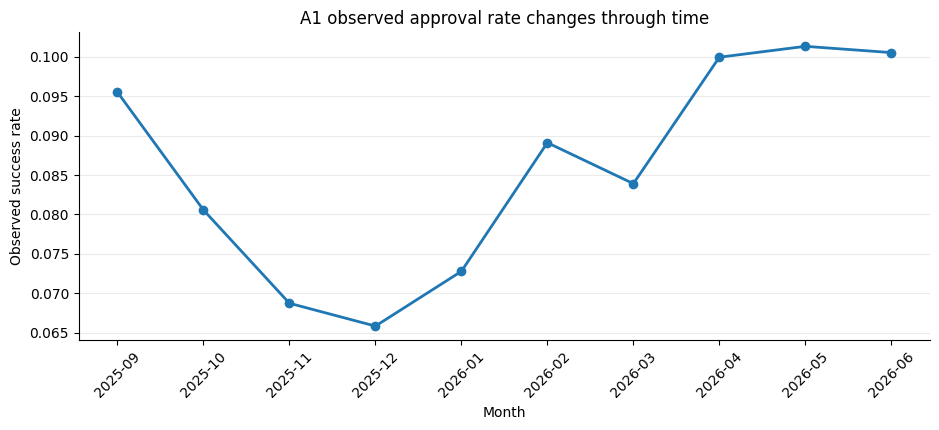

,month,adjusted_residual_pp,rows
0,2025-09,-0.323187,9903
1,2025-10,-1.281861,39944
2,2025-11,-1.814156,61748
3,2025-12,-1.716567,70027
4,2026-01,-1.923896,66906
5,2026-02,-0.009331,54899
6,2026-03,0.317401,85152
7,2026-04,1.889643,72764
8,2026-05,2.016489,93546
9,2026-06,1.546488,40545


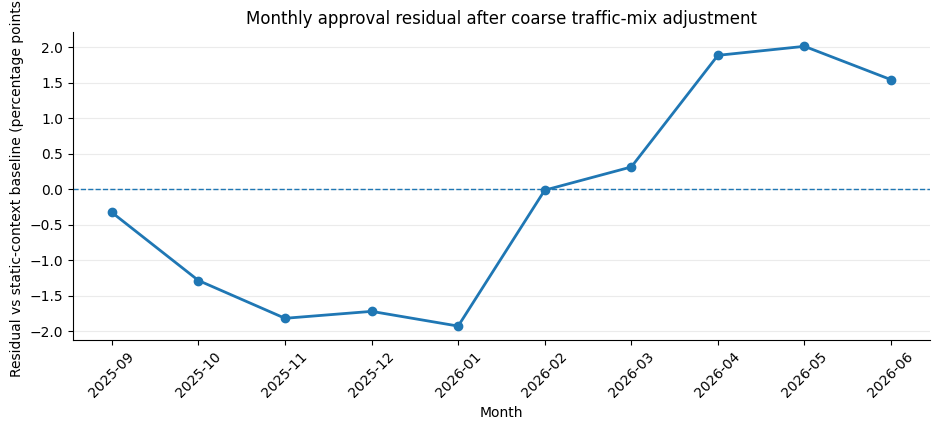

Large recurring near-comparable cohort:


,merchant_id,showcase_route,card_type,amount_decile
0,3a1d0325-2d85-4aea-98df-e1978a23647b,TSYS-PAYS-PNC-5199,DEBIT,"(2700.0, 3740.0]"


,month,rows,success_rate
12273,2025-10,685,0.065693
12274,2025-11,2030,0.039409
12275,2025-12,3861,0.043512
12276,2026-01,4432,0.042193
12277,2026-02,1214,0.060132
12278,2026-03,2015,0.069975
12279,2026-04,3486,0.106713
12280,2026-05,7776,0.106610
12281,2026-06,2483,0.106323


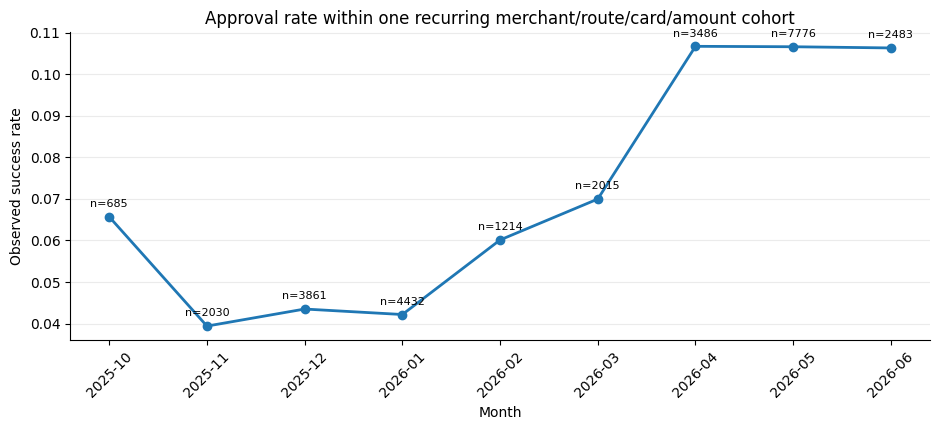

In [6]:
a1 = attempts[attempts["attempt"].eq(1)].copy()
a1["month"] = a1["timestamp"].dt.strftime("%Y-%m")

# ------------------------------------------------------------
# View 1: raw chronological approval rate
# ------------------------------------------------------------
monthly_raw = (
    a1.groupby("month", as_index=False)
      .agg(
          raw_success_rate=("success", "mean"),
          rows=("success", "size"),
      )
)

display(monthly_raw)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(
    monthly_raw["month"],
    monthly_raw["raw_success_rate"],
    marker="o",
    linewidth=2,
)
ax.set_title("A1 observed approval rate changes through time")
ax.set_xlabel("Month")
ax.set_ylabel("Observed success rate")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# View 2: approximate traffic-mix adjustment.
#
# Each row is compared with the long-run success rate for a
# static context: merchant × route × card type × amount decile.
# ------------------------------------------------------------
context_cols = [
    "merchant_id",
    "showcase_route",
    "card_type",
    "amount_decile",
]

context_rate = (
    a1.groupby(context_cols, dropna=False)["success"]
      .agg(context_success_rate="mean", context_rows="size")
      .reset_index()
)

drift_frame = a1.merge(
    context_rate,
    on=context_cols,
    how="left",
    validate="many_to_one",
)

drift_frame["mix_adjusted_residual"] = (
    drift_frame["success"] - drift_frame["context_success_rate"]
)

monthly_adjusted = (
    drift_frame.groupby("month", as_index=False)
               .agg(
                   adjusted_residual=("mix_adjusted_residual", "mean"),
                   rows=("success", "size"),
               )
)

monthly_adjusted["adjusted_residual_pp"] = (
    100 * monthly_adjusted["adjusted_residual"]
)

display(monthly_adjusted[["month", "adjusted_residual_pp", "rows"]])

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.axhline(0, linestyle="--", linewidth=1)
ax.plot(
    monthly_adjusted["month"],
    monthly_adjusted["adjusted_residual_pp"],
    marker="o",
    linewidth=2,
)
ax.set_title("Monthly approval residual after coarse traffic-mix adjustment")
ax.set_xlabel("Month")
ax.set_ylabel("Residual vs static-context baseline (percentage points)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# View 3: one large recurring near-comparable cohort.
# Pick the highest-volume context that appears in >=5 months.
# This is selected by volume/stability, NOT by amount of drift.
# ------------------------------------------------------------
cohort_month = (
    a1.groupby(context_cols + ["month"], dropna=False)
      .agg(
          rows=("success", "size"),
          success_rate=("success", "mean"),
      )
      .reset_index()
)

cohort_quality = (
    cohort_month.groupby(context_cols, dropna=False)
                .agg(
                    months=("month", "nunique"),
                    total_rows=("rows", "sum"),
                    median_month_rows=("rows", "median"),
                )
                .reset_index()
)

eligible = cohort_quality[
    (cohort_quality["months"] >= 5)
    & (cohort_quality["median_month_rows"] >= 50)
].copy()

if eligible.empty:
    eligible = cohort_quality[
        cohort_quality["months"] >= 4
    ].copy()

if not eligible.empty:
    chosen_context = (
        eligible.sort_values("total_rows", ascending=False)
                .iloc[0]
    )

    mask = np.ones(len(cohort_month), dtype=bool)
    for c in context_cols:
        value = chosen_context[c]
        if pd.isna(value):
            mask &= cohort_month[c].isna().to_numpy()
        else:
            mask &= cohort_month[c].eq(value).to_numpy()

    cohort = cohort_month.loc[mask].sort_values("month")

    print("Large recurring near-comparable cohort:")
    display(
        pd.DataFrame([{
            c: chosen_context[c]
            for c in context_cols
        }])
    )
    display(cohort[["month", "rows", "success_rate"]])

    fig, ax = plt.subplots(figsize=(9.5, 4.4))
    ax.plot(
        cohort["month"],
        cohort["success_rate"],
        marker="o",
        linewidth=2,
    )
    for _, row in cohort.iterrows():
        ax.annotate(
            f"n={int(row['rows'])}",
            (row["month"], row["success_rate"]),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )
    ax.set_title(
        "Approval rate within one recurring merchant/route/card/amount cohort"
    )
    ax.set_xlabel("Month")
    ax.set_ylabel("Observed success rate")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("No recurring cohort passed the minimum-volume threshold.")

### Interpretation

The first plot shows the business-level chronological change.

The second asks whether that change survives a coarse static-context adjustment. A residual above zero means transactions in that month performed better than the long-run rate of approximately similar merchant/route/card/amount traffic; below zero means worse.

The recurring-cohort view is even narrower: the merchant, route, card type and amount bucket are held approximately constant while the month changes.

Together these are stronger evidence that a purely static representation is insufficient. They do **not** prove a particular causal source of drift; they motivate a model whose state can adapt through time.

## 4. Route signal after basic traffic-mix adjustment

In [7]:
# Descriptive/predictive diagnostic — NOT a causal estimate.
tmp = a1[["merchant_id", "showcase_route", "month", "success", "amount", "amount_decile"]].copy()
keys = ["merchant_id", "month", "amount_decile"]
tmp["group_baseline"] = tmp.groupby(keys, observed=True)["success"].transform("mean")
tmp["residual"] = tmp["success"] - tmp["group_baseline"]

route_res = (
    tmp.groupby("showcase_route")
    .agg(
        rows=("success", "size"),
        raw_success=("success", "mean"),
        residual=("residual", "mean"),
    )
    .query("rows >= 1000")
    .sort_values("residual", ascending=False)
)
display(route_res.head(12))

,rows,raw_success,residual
showcase_route,,,
STRI-STRI-PNC-5199,6684,0.180580,0.090000
FISE-BRAI-DEUT-5199,3829,0.153304,0.049762
FISE-PAYS-PNC-5199,64535,0.099450,0.014121
TSYS-PAYN-NORT-5099,3267,0.114478,0.007112
TSYS-CLIQ-NORT-5199,46489,0.087311,0.004888
TSYS-NUVE-NORT-5199,1140,0.086842,0.001533
TSYS-QUAN-FRES-5099,18409,0.079744,0.000165
TSYS-PAYN-NORT-5199,8160,0.106127,-0.001657
TSYS-REDW-WEST-5199,4609,0.091343,-0.003101


# Part III — Feature engineering: giving a tabular model state

Before comparing model families, the **information available to the model must be defined**.

A model-family comparison is only meaningful after fixing the feature representation. Otherwise an apparent gain may come from giving one model richer information rather than from the learning algorithm itself.

The feature engineering developed in two main directions:

1. **temporal state** — so the model can represent a changing payment environment;
2. **cross / interaction features** — so the model can represent transaction–route compatibility.

A static model sees the current transaction $X_t$ but not what has been happening recently. The first temporal solution was fixed rolling windows. Their weakness is an arbitrary cutoff: an observation just inside the window receives full weight, while one just outside disappears.

Instead, historical relevance fades continuously:

$$
w(\Delta t)=0.5^{\Delta t/h}.
$$

Multiple half-lives $h\in\{3,14,60,180\}$ expose several speeds of change to the downstream model.

## 5. Continuous-memory intuition

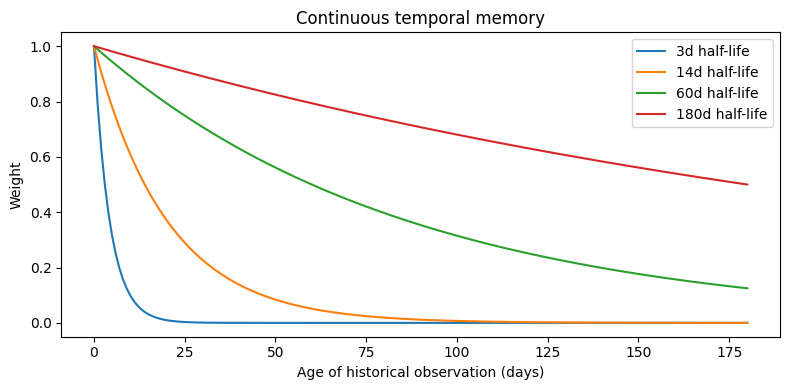

In [8]:
ages=np.arange(0,181)
fig,ax=plt.subplots(figsize=(8,4))
for h in [3,14,60,180]:
    ax.plot(ages,0.5**(ages/h),label=f'{h}d half-life')
ax.set(title='Continuous temporal memory',xlabel='Age of historical observation (days)',ylabel='Weight')
ax.legend(); plt.tight_layout(); plt.show()

### Leakage rule

For a transaction at time $t$, historical state is emitted **before** adding outcomes at $t$. Thus all temporal features obey the information set available at decision time. A2 may additionally use the observed A1 response; A3 may use A1 and A2 state.

## 5.1 Cross-feature engineering — modeling route compatibility

A route is not universally “good” or “bad”. Its approval probability can depend on the transaction being sent through it.

Knowing separately that a merchant usually performs well and that a route usually performs well does not fully represent:

$$
P(Y=1 \mid Merchant,\ Route)
$$

The routing decision is therefore better framed as:

> **Which route is best for this specific transaction and context?**

To expose that compatibility directly, the feature engineering includes explicit interaction/cross features.

Examples include static route-context crosses such as:

- `bankcat_route`
- `cardnetwork_route`
- `cardtype_route`
- `cardlevel_route`
- `mcc_route`

and historical interaction state such as:

- `merchant_route`
- `issuer_route`
- `bankcat_route`
- `cardtype_route`
- `mcc_route`

For example, instead of only maintaining a recent success estimate for Route A, the model can also receive a leakage-safe historical estimate for:

$$
P_t(Y=1 \mid Merchant=M,\ Route=A)
$$

or:

$$
P_t(Y=1 \mid Issuer=I,\ Route=A)
$$

using the same expanding / exponentially decayed history described above.

This matters because two routes with similar global performance can behave very differently for a particular merchant, issuer or card population.

XGBoost can learn nonlinear interactions from separate columns by itself. The explicit crosses are therefore **not added because trees cannot model interactions**. They are added because some joint entities — especially `merchant × route` and `issuer × route` historical state — have direct business meaning and allow the model to maintain statistics at exactly the level at which the routing decision is made.

### Did the model actually use the cross features?

The next cell re-reads the frozen XGBoost feature-importance artifact and measures the **normalized total gain assigned to explicit interaction features**.

This is model-internal predictive evidence, not a causal effect or an ablation test. It answers the narrower question:

> **Once these cross features were available, did the fitted models actually spend split gain on them?**

One important bookkeeping detail: the later feature-family chart groups `hist__*` and `decay__*` columns under **historical temporal state**. Therefore a feature such as `decay__merchant_route__rate__hl14p0d` is both:

- a temporal-history feature in the later family chart; and
- a cross/interaction feature in the analysis below.

The two views are intentionally complementary rather than additive.

Normalized XGBoost total gain attributed to explicit cross / interaction features:


,attempt,cross_features,cross_gain_pct
0,1,109,55.03%
1,2,53,41.10%
2,3,53,46.27%


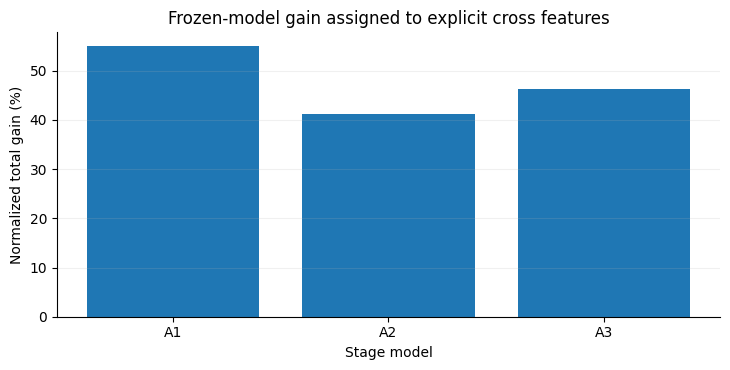


Highest-gain cross features — with rank among ALL features in the same model:


,attempt,overall_gain_rank,feature,cross_type,gain_pct
0,1,1,hist__issuer_cardtype__rate__exp,historical cross,14.641%
3,1,4,bankcat_route,static cross,3.544%
5,1,6,cardlevel_route,static cross,2.568%
8,1,9,decay__merchant_route__rate__hl14p0d,historical cross,2.424%
9,1,10,decay__issuer_route__rate__hl14p0d,historical cross,2.400%
10,1,11,decay__merchant_route__rate__hl3p0d,historical cross,2.078%
11,1,12,hist__merchant_amount__rate__exp,historical cross,2.050%
13,1,14,decay__issuer_route__rate__hl3p0d,historical cross,1.831%
230,2,2,bankcat_current_route,static cross,19.816%
232,2,4,hist__merchant_route__rate__hl14p0d,historical cross,5.267%



Interpretation: a high rank means the interaction is not merely present in the feature matrix; the fitted XGBoost model used it materially when reducing training loss.


In [9]:
# ------------------------------------------------------------
# Cross-feature contribution from the exact frozen XGBoost
# importance artifact.
# ------------------------------------------------------------

cross_fi_roots = [
    p for p in [
        ART.get("feature_policy"),
        DRIVE_ROOT / "flexfactor_policy_v2/feature_importance_lp_online_v1",
    ]
    if p is not None
]

cross_fi_path = None

for root in cross_fi_roots:
    for rel in [
        "feature_importance/specific_feature_importance.csv",
        "feature_importance/feature_importance_all.csv",
    ]:
        candidate = Path(root) / rel
        if candidate.exists():
            cross_fi_path = candidate
            break
    if cross_fi_path is not None:
        break

if cross_fi_path is None:
    print(
        "Exact individual feature-importance artifact not found. "
        "The cross-feature proof will appear when the authorized Drive "
        "artifact is available."
    )

else:
    cross_raw = pd.read_csv(cross_fi_path).copy()

    # The saved artifact has evolved slightly across notebook versions.
    # Normalize it to one common percentage-of-total-gain column.
    if "normalized_total_gain" in cross_raw.columns:
        cross_raw["gain_pct"] = (
            pd.to_numeric(
                cross_raw["normalized_total_gain"],
                errors="coerce",
            )
            * 100
        )

    elif "importance_pct" in cross_raw.columns:
        cross_raw["gain_pct"] = pd.to_numeric(
            cross_raw["importance_pct"],
            errors="coerce",
        )

    elif "total_gain" in cross_raw.columns:
        cross_raw["total_gain"] = pd.to_numeric(
            cross_raw["total_gain"],
            errors="coerce",
        ).fillna(0)

        cross_raw["gain_pct"] = (
            cross_raw.groupby("attempt")["total_gain"]
                     .transform(
                         lambda s: 100 * s / s.sum()
                         if s.sum() > 0
                         else 0
                     )
        )

    else:
        raise KeyError(
            "Feature-importance artifact contains no recognized gain column."
        )

    # Explicit static crosses used by the A1/A2/A3 model schemas.
    static_crosses = {
        "bankcat_route",
        "cardnetwork_route",
        "cardtype_route",
        "cardlevel_route",
        "mcc_route",
        "bankcat_current_route",
        "cardtype_current_route",
        "mcc_current_route",
    }

    # Interaction groups used inside historical / decayed / retry state.
    interaction_specs = {
        "merchant_route",
        "issuer_route",
        "bankcat_route",
        "cardtype_route",
        "cardlevel_route",
        "mcc_route",
        "merchant_amount",
        "issuer_cardtype",
        "issuer_processor",
        "issuer_sponsor",
        "bankcat_processor",
        "bankcat_sponsor",
        "merchant_processor",
        "merchant_sponsor",
        "merchant_a1_route",
        "issuer_a1_route",
        "bankcat_a1_route",
        "cardtype_a1_route",
    }

    def classify_cross_feature(feature):
        f = str(feature)

        if f in static_crosses:
            return "static cross"

        # History names have forms such as:
        # hist__merchant_route__rate__exp
        # decay__issuer_route__rate__hl14p0d
        # retry__merchant_a1_route__eventual_rate
        parts = f.split("__")

        if len(parts) >= 2 and parts[0] in {
            "hist",
            "decay",
            "retry",
        }:
            if parts[1] in interaction_specs:
                return "historical cross"

        return None

    cross_raw["cross_type"] = (
        cross_raw["feature"]
        .map(classify_cross_feature)
    )

    cross_only = cross_raw[
        cross_raw["cross_type"].notna()
    ].copy()

    # Rank every feature within each model, so the cross-feature table
    # can be linked directly to the later individual-feature ranking.
    cross_raw["overall_gain_rank"] = (
        cross_raw.groupby("attempt")["gain_pct"]
                 .rank(
                     method="min",
                     ascending=False,
                 )
                 .astype("Int64")
    )

    cross_only = cross_raw[
        cross_raw["cross_type"].notna()
    ].copy()

    cross_summary = (
        cross_only.groupby(
            ["attempt", "cross_type"],
            as_index=False,
        )
        .agg(
            cross_features=("feature", "nunique"),
            normalized_total_gain_pct=("gain_pct", "sum"),
        )
    )

    cross_total = (
        cross_only.groupby(
            "attempt",
            as_index=False,
        )
        .agg(
            cross_features=("feature", "nunique"),
            cross_gain_pct=("gain_pct", "sum"),
        )
    )

    print(
        "Normalized XGBoost total gain attributed to explicit "
        "cross / interaction features:"
    )

    display(
        cross_total.style.format({
            "cross_gain_pct": "{:.2f}%",
        })
    )

    # Small visual: contribution of cross features within each stage.
    fig, ax = plt.subplots(figsize=(7.4, 3.8))

    ax.bar(
        [f"A{int(a)}" for a in cross_total["attempt"]],
        cross_total["cross_gain_pct"],
    )

    ax.set_title(
        "Frozen-model gain assigned to explicit cross features"
    )
    ax.set_ylabel("Normalized total gain (%)")
    ax.set_xlabel("Stage model")
    ax.grid(axis="y", alpha=0.18)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(
        "\nHighest-gain cross features — with rank among ALL "
        "features in the same model:"
    )

    top_cross = (
        cross_only.sort_values(
            ["attempt", "gain_pct"],
            ascending=[True, False],
        )
        .groupby("attempt", group_keys=False)
        .head(8)
    )

    display(
        top_cross[
            [
                "attempt",
                "overall_gain_rank",
                "feature",
                "cross_type",
                "gain_pct",
            ]
        ].style.format({
            "gain_pct": "{:.3f}%",
        })
    )

    print(
        "\nInterpretation: a high rank means the interaction is not "
        "merely present in the feature matrix; the fitted XGBoost model "
        "used it materially when reducing training loss."
    )

# Part IV — Model selection: compare learners after fixing the feature space

Only after the temporal and cross-feature representation was defined did the project compare model families.

This ordering matters:

> **Feature engineering defines what information the learner receives; model selection asks which learner uses that same information best.**

The A1 comparison therefore evaluates model families on the same frozen feature architecture and chronological development folds before tuning the selected family.

Compared families:

- CatBoost — native categorical handling;
- LightGBM — efficient gradient-boosting baseline;
- XGBoost — final selected family;
- linear SGD / logistic model — sanity baseline.

The notebook loads the original saved comparison rather than reconstructing an after-the-fact benchmark.

## 6. Original model-family comparison

In [10]:
model_sel = ART["a1_model_selection"]
arch_path = (model_sel / "summary/architecture_aggregate.csv") if model_sel else None
walk_path = (model_sel / "summary/architecture_walk_forward.csv") if model_sel else None

if arch_path and arch_path.exists():
    arch = pd.read_csv(arch_path)
    print("Same-feature, same chronological folds, default-configuration family comparison:")
    display(arch)
    if walk_path and walk_path.exists():
        walk = pd.read_csv(walk_path)
        print("Per-fold results:")
        display(walk)
else:
    print("Architecture comparison checkpoint not found.")
    print("Historical development path: LightGBM feasibility → CatBoost/history experiments → final tuned XGBoost.")

Same-feature, same chronological folds, default-configuration family comparison:


,family,folds,total_rows,mean_auc,std_auc,mean_ap,mean_ap_lift,mean_logloss,mean_normalized_logloss,mean_logloss_skill,mean_brier,mean_ece,mean_success_rate,mean_best_iterations
0,xgboost,5,373267,0.789552,0.019738,0.303951,3.459887,0.252745,0.839951,0.160049,0.071592,0.009120,0.089422,164.6
1,catboost,5,373267,0.789474,0.019744,0.307932,3.497520,0.252090,0.837913,0.162087,0.071387,0.006411,0.089422,600.6
2,lightgbm,5,373267,0.787705,0.019700,0.304581,3.468715,0.253109,0.841127,0.158873,0.071592,0.007486,0.089422,114.0
3,linear_logistic_sgd,5,373267,0.537692,0.021435,0.125621,1.429528,1.415918,4.698600,-3.698600,0.089328,0.089295,0.089422,50.0


Per-fold results:


,rows,success_rate,roc_auc,average_precision,ap_lift_vs_prevalence,logloss,fold_entropy_logloss,normalized_logloss,logloss_skill,train_prior_logloss,...,predicted_mean,stage,family,validation_month,train_rows,train_success_rate,features,best_iterations,run_key,params
0,66906,0.072774,0.822649,0.325938,4.478790,0.208112,0.260755,0.798113,0.201887,0.260765,...,0.076452,architecture,catboost,2026-01,181622,0.071665,229,650,default,"{'iterations': 650, 'depth': 6, 'learning_rate..."
1,66906,0.072774,0.821231,0.335054,4.604047,0.208044,0.260755,0.797850,0.202150,0.260765,...,0.073886,architecture,lightgbm,2026-01,181622,0.071665,229,69,default,"{'n_estimators': 650, 'learning_rate': 0.05, '..."
2,66906,0.072774,0.823069,0.332426,4.567940,0.207965,0.260755,0.797548,0.202452,0.260765,...,0.077266,architecture,xgboost,2026-01,181622,0.071665,229,104,default,"{'n_estimators': 650, 'learning_rate': 0.05, '..."
3,66906,0.072774,0.569925,0.136625,1.877398,1.164964,0.260755,4.467651,-3.467651,0.260765,...,0.021594,architecture,linear_logistic_sgd,2026-01,181622,0.071665,229,50,default,"{'alpha': 1e-05, 'max_iter': 50}"
4,54899,0.089109,0.776961,0.320044,3.591592,0.254884,0.300472,0.848280,0.151720,0.302528,...,0.080156,architecture,catboost,2026-02,248528,0.071964,229,592,default,"{'iterations': 650, 'depth': 6, 'learning_rate..."
5,54899,0.089109,0.775919,0.318463,3.573854,0.255935,0.300472,0.851776,0.148224,0.302528,...,0.079778,architecture,lightgbm,2026-02,248528,0.071964,229,89,default,"{'n_estimators': 650, 'learning_rate': 0.05, '..."
6,54899,0.089109,0.774646,0.313063,3.513252,0.256340,0.300472,0.853124,0.146876,0.302528,...,0.083689,architecture,xgboost,2026-02,248528,0.071964,229,168,default,"{'n_estimators': 650, 'learning_rate': 0.05, '..."
7,54899,0.089109,0.546789,0.140845,1.580585,1.384367,0.300472,4.607312,-3.607312,0.302528,...,0.013995,architecture,linear_logistic_sgd,2026-02,248528,0.071964,229,50,default,"{'alpha': 1e-05, 'max_iter': 50}"
8,85152,0.083909,0.772352,0.271902,3.240453,0.247882,0.288214,0.860065,0.139935,0.288758,...,0.087426,architecture,catboost,2026-03,303427,0.075066,229,462,default,"{'iterations': 650, 'depth': 6, 'learning_rate..."
9,85152,0.083909,0.772035,0.266489,3.175943,0.248434,0.288214,0.861979,0.138021,0.288758,...,0.084927,architecture,lightgbm,2026-03,303427,0.075066,229,128,default,"{'n_estimators': 650, 'learning_rate': 0.05, '..."


# Part V — Final A1/A2/A3 predictive models

Separate models are used because the information set changes after each failed attempt:

$$
P(S_1\mid X,r_1,H_t)
$$

$$
P(S_2\mid X,r_2,A1_{observed},H_t)
$$

$$
P(S_3\mid X,r_3,A1_{observed},A2_{observed},H_t)
$$

The metrics below are evaluated on the **historically observed route**, where the outcome is factual rather than counterfactual.

## 7. Factual chronological predictive performance and overall calibration

In [11]:
predictive_path = (
    PROJECT_ROOT
    / "artifacts"
    / "reference_predictive_metrics.csv"
)

predictive = pd.read_csv(predictive_path)

stage_prediction_paths = {
    "A1": ART.get("a1_predictions"),
    "A2": ART.get("a2_predictions"),
    "A3": ART.get("a3_predictions"),
}

stage_predictions = {}
overall_rows = []

for stage, path in stage_prediction_paths.items():
    if path is None or not Path(path).exists():
        continue

    pred = pd.read_parquet(path)
    y_col = "y" if "y" in pred.columns else "success"
    p_col = "p" if "p" in pred.columns else "model_score"

    pred = pred[[y_col, p_col]].copy()
    pred[y_col] = pd.to_numeric(pred[y_col], errors="coerce")
    pred[p_col] = pd.to_numeric(pred[p_col], errors="coerce")
    pred = pred.dropna()

    stage_predictions[stage] = (pred, y_col, p_col)

    actual = float(pred[y_col].mean())
    mean_pred = float(pred[p_col].mean())

    overall_rows.append({
        "stage": stage,
        "observed_logged_route_success": actual,
        "mean_predicted_probability": mean_pred,
        "mean_calibration_gap": mean_pred - actual,
    })

overall_calibration = pd.DataFrame(overall_rows)

performance = predictive.merge(
    overall_calibration,
    on="stage",
    how="left",
)

performance["AP_lift_vs_prevalence"] = (
    performance["average_precision"]
    / performance["success_rate"]
)

display(
    performance[[
        "stage",
        "rows",
        "observed_logged_route_success",
        "mean_predicted_probability",
        "mean_calibration_gap",
        "roc_auc",
        "average_precision",
        "AP_lift_vs_prevalence",
        "logloss_skill",
        "brier",
        "ece",
    ]]
    .style.format({
        "observed_logged_route_success": "{:.4%}",
        "mean_predicted_probability": "{:.4%}",
        "mean_calibration_gap": "{:+.4%}",
        "roc_auc": "{:.4f}",
        "average_precision": "{:.4f}",
        "AP_lift_vs_prevalence": "{:.2f}×",
        "logloss_skill": "{:.4f}",
        "brier": "{:.5f}",
        "ece": "{:.5f}",
    })
)

,stage,rows,observed_logged_route_success,mean_predicted_probability,mean_calibration_gap,roc_auc,average_precision,AP_lift_vs_prevalence,logloss_skill,brier,ece
0,A1,40545,10.0555%,9.8564%,-0.1991%,0.7969,0.3239,3.22×,0.1708,0.07885,0.00546
1,A2,24993,5.0774%,5.1174%,+0.0400%,0.7941,0.2120,4.17×,0.1514,0.04404,0.00191
2,A3,8988,1.9582%,2.1048%,+0.1467%,0.8709,0.1370,7.00×,0.2069,0.01803,0.00264


The **observed logged-route success rate** and **mean predicted probability** provide the simplest calibration sanity check: averaged over all June rows, the model should predict approximately the same amount of success that actually occurred.

That overall agreement is necessary but not sufficient. A model could get the average right while being badly calibrated inside probability ranges, which is why the next section uses a reliability diagram.

## 7.1 Calibration / reliability on untouched June predictions

Because the optimizer uses the **magnitude** of $\hat p$, not only the ranking, calibration matters directly to the routing decision.

The reliability diagram returns to the simpler **fixed probability bins** used in the earlier analysis:

- each point represents a predicted-probability range;
- the x-axis is the mean predicted probability inside that bin;
- the y-axis is the approval rate actually observed on the logged route.

This makes it easy to see whether, for example, transactions predicted around 20% actually succeeded around 20% of the time.

The extreme A2/A3 probability ranges contain very few observations, so their sample counts are reported directly below the graph rather than giving those isolated points the same statistical interpretation as the well-populated part of the curve.

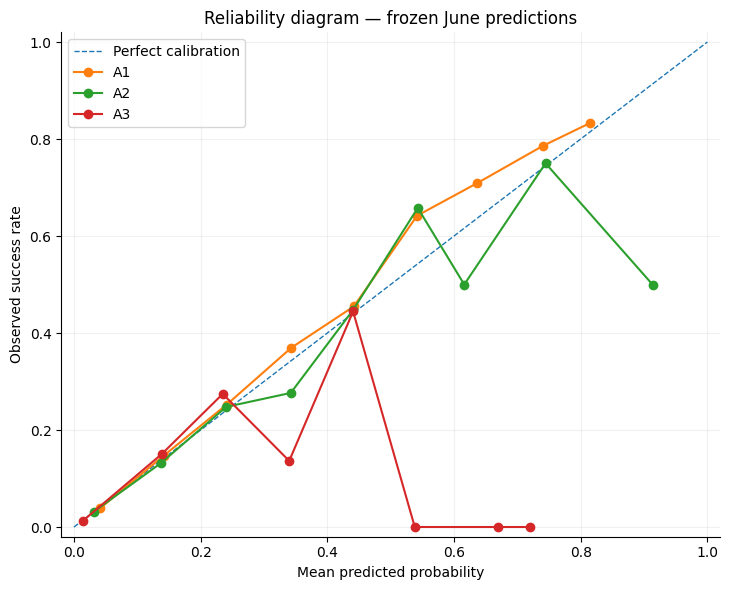

High-probability bins — sample size behind the visually unusual points:


,stage,probability_bin,rows,share_of_stage,mean_predicted_probability,observed_success_rate,absolute_gap
0,A1,"[0.5, 0.6)",162,0.3996%,0.542,0.642,0.100
1,A1,"[0.6, 0.7)",55,0.1357%,0.637,0.709,0.072
2,A1,"[0.7, 0.8)",14,0.0345%,0.740,0.786,0.046
3,A1,"[0.8, 0.9)",6,0.0148%,0.815,0.833,0.018
4,A2,"[0.5, 0.6)",38,0.1520%,0.543,0.658,0.115
5,A2,"[0.6, 0.7)",4,0.0160%,0.616,0.500,0.116
6,A2,"[0.7, 0.8)",4,0.0160%,0.745,0.750,0.005
7,A2,"[0.9, 1.0)",2,0.0080%,0.913,0.500,0.413
8,A3,"[0.5, 0.6)",2,0.0223%,0.538,0.000,0.538
9,A3,"[0.6, 0.7)",2,0.0223%,0.669,0.000,0.669



A1 calibration bins


,bin,n,predicted_mean,observed_rate,abs_gap
0,"[0.0, 0.1)",26175,0.041,0.038,0.003
1,"[0.1, 0.2)",8686,0.141,0.147,0.005
2,"[0.2, 0.3)",3566,0.241,0.252,0.011
3,"[0.3, 0.4)",1349,0.343,0.370,0.026
4,"[0.4, 0.5)",532,0.442,0.455,0.013
5,"[0.5, 0.6)",162,0.542,0.642,0.100
6,"[0.6, 0.7)",55,0.637,0.709,0.072
7,"[0.7, 0.8)",14,0.740,0.786,0.046
8,"[0.8, 0.9)",6,0.815,0.833,0.018



A2 calibration bins


,bin,n,predicted_mean,observed_rate,abs_gap
0,"[0.0, 0.1)",21661,0.031,0.032,0.000
1,"[0.1, 0.2)",2429,0.137,0.131,0.005
2,"[0.2, 0.3)",553,0.240,0.248,0.007
3,"[0.3, 0.4)",217,0.342,0.276,0.066
4,"[0.4, 0.5)",85,0.440,0.447,0.007
5,"[0.5, 0.6)",38,0.543,0.658,0.115
6,"[0.6, 0.7)",4,0.616,0.500,0.116
7,"[0.7, 0.8)",4,0.745,0.750,0.005
8,"[0.9, 1.0)",2,0.913,0.500,0.413



A3 calibration bins


,bin,n,predicted_mean,observed_rate,abs_gap
0,"[0.0, 0.1)",8629,0.014,0.013,0.001
1,"[0.1, 0.2)",272,0.139,0.151,0.012
2,"[0.2, 0.3)",51,0.235,0.275,0.040
3,"[0.3, 0.4)",22,0.340,0.136,0.203
4,"[0.4, 0.5)",9,0.441,0.444,0.004
5,"[0.5, 0.6)",2,0.538,0.000,0.538
6,"[0.6, 0.7)",2,0.669,0.000,0.669
7,"[0.7, 0.8)",1,0.721,0.000,0.721


In [12]:
def reliability_table(y_true, y_prob, n_bins=10):
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(y_prob, dtype=float)

    frame = pd.DataFrame({
        "y": y,
        "p": p,
    }).dropna()

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    frame["bin_id"] = np.digitize(
        frame["p"],
        edges[1:-1],
        right=False,
    )

    rows = []

    for b in range(n_bins):
        part = frame[frame["bin_id"].eq(b)]

        if part.empty:
            continue

        rows.append({
            "bin": f"[{edges[b]:.1f}, {edges[b+1]:.1f})",
            "n": len(part),
            "predicted_mean": part["p"].mean(),
            "observed_rate": part["y"].mean(),
            "abs_gap": abs(
                part["p"].mean()
                - part["y"].mean()
            ),
        })

    return pd.DataFrame(rows)


calibration_tables = {}

fig, ax = plt.subplots(figsize=(7.4, 6.0))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Perfect calibration",
)

for stage, (pred, y_col, p_col) in stage_predictions.items():
    rel = reliability_table(
        pred[y_col],
        pred[p_col],
        n_bins=10,
    )

    calibration_tables[stage] = rel

    ax.plot(
        rel["predicted_mean"],
        rel["observed_rate"],
        marker="o",
        linewidth=1.5,
        label=stage,
    )

ax.set_title("Reliability diagram — frozen June predictions")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed success rate")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.18)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Show where the apparent high-probability calibration failures
# come from. These bins are visually dramatic but often tiny.
# ------------------------------------------------------------
sparse_tail_rows = []

for stage, rel in calibration_tables.items():

    stage_total = len(stage_predictions[stage][0])

    # Focus only on high-probability bins, where the visually odd
    # A2/A3 points occur.
    tail = rel[rel["predicted_mean"] >= 0.50].copy()

    for _, row in tail.iterrows():
        sparse_tail_rows.append({
            "stage": stage,
            "probability_bin": row["bin"],
            "rows": int(row["n"]),
            "share_of_stage": row["n"] / stage_total,
            "mean_predicted_probability": row["predicted_mean"],
            "observed_success_rate": row["observed_rate"],
            "absolute_gap": row["abs_gap"],
        })

sparse_tail = pd.DataFrame(sparse_tail_rows)

if not sparse_tail.empty:
    print(
        "High-probability bins — sample size behind the visually unusual points:"
    )

    display(
        sparse_tail.style.format({
            "share_of_stage": "{:.4%}",
            "mean_predicted_probability": "{:.3f}",
            "observed_success_rate": "{:.3f}",
            "absolute_gap": "{:.3f}",
        })
    )
else:
    print(
        "No stage contained predictions with mean bin probability above 0.50."
    )


# Full bin tables remain available for transparency.
for stage, rel in calibration_tables.items():
    print(f"\n{stage} calibration bins")
    display(
        rel.style.format({
            "predicted_mean": "{:.3f}",
            "observed_rate": "{:.3f}",
            "abs_gap": "{:.3f}",
        })
    )

### Reading the calibration figure

The main mass of the predictions lies close to the diagonal, which is consistent with the low Brier error and ECE reported above.

The visually strange points in the extreme upper-right portion should be read together with the table immediately below the chart. In particular, A3 above roughly 0.5 predicted probability and A2 in the very highest predicted-probability range represent only a **very small number of transactions** relative to the full June stage population.

With such small samples, observing zero successes in one extreme bin is possible even if the underlying model probability is informative. Those points therefore indicate **high uncertainty in a sparse tail**, not that the model is broadly miscalibrated.

For the overall calibration judgment, the more representative evidence is the combination of:

- observed success rate vs mean predicted probability over the full stage;
- the well-populated portion of the reliability curve;
- Brier score;
- Expected Calibration Error (ECE).

The sparse tail is retained rather than hidden, but its transaction volume is shown explicitly so that it is interpreted in proportion to the evidence behind it.

# Part VI — What did the models actually use?

The previous cross-feature section looked at the feature set through a **compatibility lens**: which features explicitly combine two business entities such as merchant × route or issuer × route?

This section looks at the same frozen models through the broader feature-family lens.

The categories overlap by design. In particular, a feature such as:

`decay__merchant_route__rate__hl14p0d`

appears here under **historical temporal state**, because it is a dynamic historical feature, while Section 5.1 also identifies it as a **cross feature**, because the underlying state is conditioned on merchant × route.

This avoids double-counting while still showing both engineering ideas clearly.

## 8. Feature-family importance across A1/A2/A3

,attempt,family,normalized_total_gain,total_gain,split_uses,feature_count,importance_pct,rank
0,1,historical_temporal_state,0.627174,804661.008652,30088.0,136,62.717414,1
1,1,transaction_context,0.155081,198968.679382,8914.0,28,15.508147,2
2,1,route_and_interactions,0.143485,184090.567476,9830.0,45,14.348507,3
3,1,amount,0.056672,72709.814522,2980.0,8,5.667196,4
4,1,other,0.008866,11375.183380,1035.0,8,0.886612,5
5,1,calendar_time,0.008721,11189.296997,1177.0,4,0.872124,6
6,2,transaction_context,0.317601,58327.759644,998.0,7,31.760053,1
7,2,historical_temporal_state,0.311552,57216.947513,645.0,110,31.155204,2
8,2,route_and_interactions,0.222999,40953.999203,782.0,8,22.299865,3
9,2,prior_attempt_state,0.105520,19378.816879,503.0,5,10.551961,4


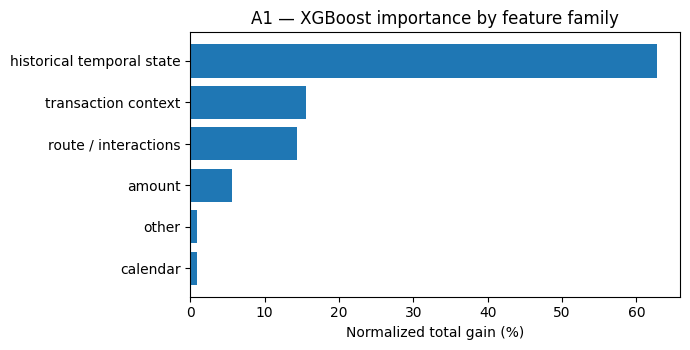

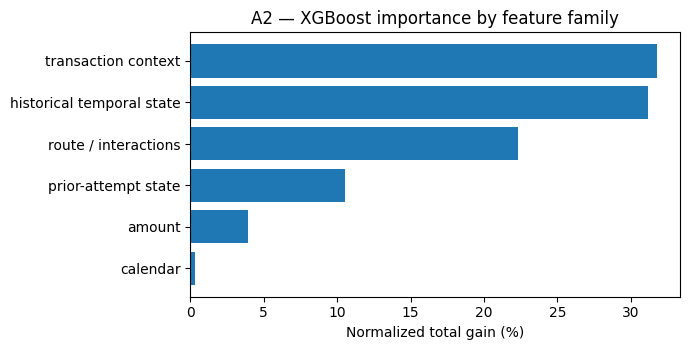

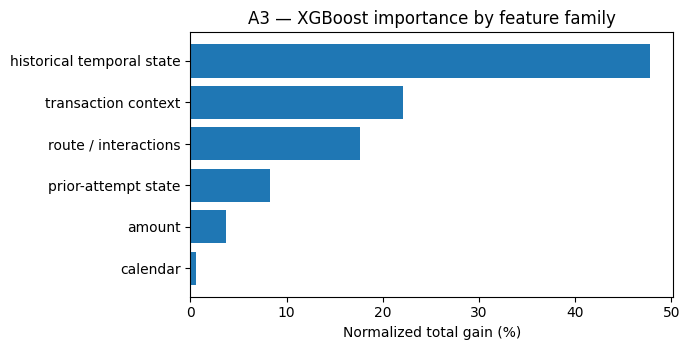

In [13]:
# Prefer the exact saved feature-importance artifact. Fall back to the frozen
# headline table copied from the completed experiment.
fi_roots=[p for p in [ART['feature_policy'], DRIVE_ROOT/'flexfactor_policy_v2/feature_importance_lp_online_v1'] if p]
fi_path=None
for r in fi_roots:
    for rel in ['feature_importance/feature_family_importance.csv','feature_importance/feature_family_importance.csv']:
        p=Path(r)/rel
        if p.exists(): fi_path=p; break
    if fi_path: break

if fi_path:
    fi=pd.read_csv(fi_path)
    display(fi)
else:
    fi=pd.read_csv(PROJECT_ROOT / "artifacts" / "reference_feature_family_importance.csv")
    display(fi)

# Clean visual using the frozen family summary.
ref_fi=pd.read_csv(PROJECT_ROOT / "artifacts" / "reference_feature_family_importance.csv")
for stage in ['A1','A2','A3']:
    g=ref_fi[ref_fi.stage.eq(stage)].sort_values('normalized_gain_pct')
    fig,ax=plt.subplots(figsize=(7,3.6))
    ax.barh(g['family'],g['normalized_gain_pct'])
    ax.set(title=f'{stage} — XGBoost importance by feature family',xlabel='Normalized total gain (%)')
    plt.tight_layout(); plt.show()

## 9. Top individual features from the frozen models

This table is the direct continuation of Section 5.1.

The cross-feature proof above already reports the strongest interaction features together with their **rank among all model features**. The complete ranking below provides the surrounding context: it shows whether those interactions sit alongside route-level, transaction-context and temporal-state features near the top of the fitted XGBoost models.

As throughout this notebook, XGBoost gain is a model-internal measure of predictive use — not a causal importance measure.

In [14]:
top_path = None
for r in fi_roots:
    for rel in [
        "feature_importance/specific_feature_importance.csv",
        "feature_importance/feature_importance_all.csv",
    ]:
        p = Path(r) / rel
        if p.exists():
            top_path = p
            break
    if top_path:
        break

specific_importance = pd.DataFrame()
if top_path:
    raw_fi = pd.read_csv(top_path)
    specific_importance = raw_fi.copy()
    for attempt_no in [1, 2, 3]:
        g = raw_fi[raw_fi["attempt"].eq(attempt_no)].copy()
        sort_col = "rank" if "rank" in g.columns else (
            "importance_pct" if "importance_pct" in g.columns else "normalized_total_gain"
        )
        ascending = sort_col == "rank"
        g = g.sort_values(sort_col, ascending=ascending).head(15)
        print(f"A{attempt_no} top individual features")
        cols = [c for c in [
            "rank", "feature", "family", "importance_pct",
            "normalized_total_gain", "total_gain", "average_gain", "split_uses"
        ] if c in g.columns]
        display(g[cols])
else:
    print("Exact individual-feature importance CSV not found; family-level importance remains available.")

A1 top individual features


,rank,feature,family,importance_pct,normalized_total_gain,total_gain,average_gain,split_uses
0,1,hist__issuer_cardtype__rate__exp,historical_temporal_state,14.641104,0.146411,187844.562500,200.260727,938.0
1,2,decay__merchant__rate__hl3p0d,historical_temporal_state,4.008377,0.040084,51427.257812,81.115547,634.0
2,3,Order_MerchantId,transaction_context,3.830926,0.038309,49150.566406,40.024891,1228.0
3,4,bankcat_route,route_and_interactions,3.544245,0.035442,45472.472656,46.927216,969.0
4,5,decay__amount_exact__rate__hl14p0d,historical_temporal_state,3.100946,0.031009,39784.964844,56.352642,706.0
5,6,cardlevel_route,route_and_interactions,2.568013,0.025680,32947.460938,37.957905,868.0
6,7,BinCheck_IssuerName,transaction_context,2.540425,0.025404,32593.511719,40.238903,810.0
7,8,amount_numeric,amount,2.511693,0.025117,32224.880859,22.903255,1407.0
8,9,decay__merchant_route__rate__hl14p0d,historical_temporal_state,2.423563,0.024236,31094.181641,100.303810,310.0
9,10,decay__issuer_route__rate__hl14p0d,historical_temporal_state,2.399580,0.023996,30786.484375,90.282944,341.0


A2 top individual features


,rank,feature,family,importance_pct,normalized_total_gain,total_gain,average_gain,split_uses
229,1,BinCheck_IssuerName,transaction_context,23.372452,0.233725,42923.820312,71.539703,600.0
230,2,bankcat_current_route,route_and_interactions,19.816285,0.198163,36392.871094,58.228592,625.0
231,3,a1_response_key,prior_attempt_state,8.258274,0.082583,15166.429688,37.727436,402.0
232,4,hist__merchant_route__rate__hl14p0d,historical_temporal_state,5.266820,0.052668,9672.585938,1074.731812,9.0
233,5,amount_numeric,amount,3.927941,0.039279,7213.715332,103.053078,70.0
234,6,BinCheck_CardLevel,transaction_context,3.518365,0.035184,6461.524414,41.156208,157.0
235,7,Order_MerchantId,transaction_context,3.341719,0.033417,6137.111816,31.964125,192.0
236,8,hist__merchant__rate__hl3p0d,historical_temporal_state,2.986672,0.029867,5485.062500,609.451416,9.0
237,9,hist__merchant_route__rate__hl3p0d,historical_temporal_state,2.702897,0.027029,4963.906738,709.129517,7.0
238,10,cardtype_current_route,route_and_interactions,2.460895,0.024609,4519.467285,30.129782,150.0


A3 top individual features


,rank,feature,family,importance_pct,normalized_total_gain,total_gain,average_gain,split_uses
364,1,bankcat_current_route,route_and_interactions,11.131061,0.111311,3949.289062,47.015347,84.0
365,2,hist__bankcat_route__rate__hl14p0d,historical_temporal_state,9.684935,0.096849,3436.205078,214.762817,16.0
366,3,BinCheck_CardLevel,transaction_context,6.804578,0.068046,2414.257324,24.889252,97.0
367,4,BinCheck_IssuerName,transaction_context,5.718077,0.057181,2028.768066,25.359600,80.0
368,5,cardtype_current_route,route_and_interactions,5.417187,0.054172,1922.012329,26.328936,73.0
369,6,Order_MerchantId,transaction_context,4.821987,0.048220,1710.836060,21.656153,79.0
370,7,a1_response_key,prior_attempt_state,4.276605,0.042766,1517.335205,15.805575,96.0
371,8,BankCategory,transaction_context,4.211709,0.042117,1494.309937,23.348593,64.0
372,9,amount_numeric,amount,3.740014,0.037400,1326.953247,19.514019,68.0
373,10,hist__merchant_route__rate__hl60p0d,historical_temporal_state,3.492781,0.034928,1239.235107,95.325775,13.0


# Part VII — Exact frozen configuration audit

The reported results are linked to the **actual saved A1/A2/A3 metadata** rather than approximate hyperparameters typed into the showcase.

The notebook exports compact GitHub-friendly configs containing:

- exact XGBoost parameters;
- exact final tree count;
- exact feature list;
- categorical/numeric schema;
- stage architecture;
- historical half-lives and leakage rules.

Large categorical-level maps remain with the Drive model artifacts.

In [15]:
exported = export_exact_configs(ART, LOCAL_REPO / "configs")

for stage, path in exported.items():
    print(stage, "->", path)

for stage in ["a1", "a2", "a3"]:
    p = LOCAL_REPO / "configs" / f"{stage}_final.json"
    if not p.exists():
        continue
    cfg = json.load(open(p))
    print("\n", stage.upper())
    display(pd.DataFrame([{
        "family": cfg.get("family"),
        "architecture": cfg.get("architecture"),
        "iterations": cfg.get("iterations"),
        "feature_count": cfg.get("feature_count"),
        "categorical_features": cfg.get("categorical_feature_count"),
        "numeric_features": cfg.get("numeric_feature_count"),
        "final_test_month": cfg.get("final_test_month"),
    }]))
    print("Exact parameters:")
    print(json.dumps(cfg.get("params"), indent=2))

A1 -> /content/flexfactor-routing-final-project/configs/a1_final.json
A2 -> /content/flexfactor-routing-final-project/configs/a2_final.json
A3 -> /content/flexfactor-routing-final-project/configs/a3_final.json
POLICY -> /content/flexfactor-routing-final-project/configs/policy_final.json

 A1


,family,architecture,iterations,feature_count,categorical_features,numeric_features,final_test_month
0,xgboost,None,167,229,18,211,2026-06


Exact parameters:
{
  "learning_rate": 0.03268396148966359,
  "max_depth": 10,
  "min_child_weight": 12.057126287443763,
  "subsample": 0.8595304694689628,
  "colsample_bytree": 0.7046065241548528,
  "reg_alpha": 1.1091814877139725e-05,
  "reg_lambda": 0.0017775399007348214,
  "gamma": 2.5985284373248057
}

 A2


,family,architecture,iterations,feature_count,categorical_features,numeric_features,final_test_month
0,xgboost,prior_state_history,212,135,19,116,2026-06


Exact parameters:
{
  "learning_rate": 0.07989307619129249,
  "max_depth": 4,
  "min_child_weight": 4.723898532927978,
  "subsample": 0.8478170475569933,
  "colsample_bytree": 0.6881407263775413,
  "reg_alpha": 1.0711802135420363e-05,
  "reg_lambda": 17.117295635659133,
  "gamma": 0.8146804611358459
}

 A3


,family,architecture,iterations,feature_count,categorical_features,numeric_features,final_test_month
0,xgboost,prior_state_history,84,141,24,117,2026-06


Exact parameters:
{
  "learning_rate": 0.07250636837294018,
  "max_depth": 5,
  "min_child_weight": 5.742187938971849,
  "subsample": 0.8474902845433298,
  "colsample_bytree": 0.659390518122475,
  "reg_alpha": 2.185554514100498,
  "reg_lambda": 1.485927390227763,
  "gamma": 1.4790716943068847
}


# Part VIII — Final system architecture

The system has two different operating modes:

- **offline learning / benchmarking**, where historical data can be processed in batch;
- **online decisioning**, where a route must be selected for the current transaction before future transactions are known.

The LP belongs to the first mode only. The pressure policy belongs to the second.

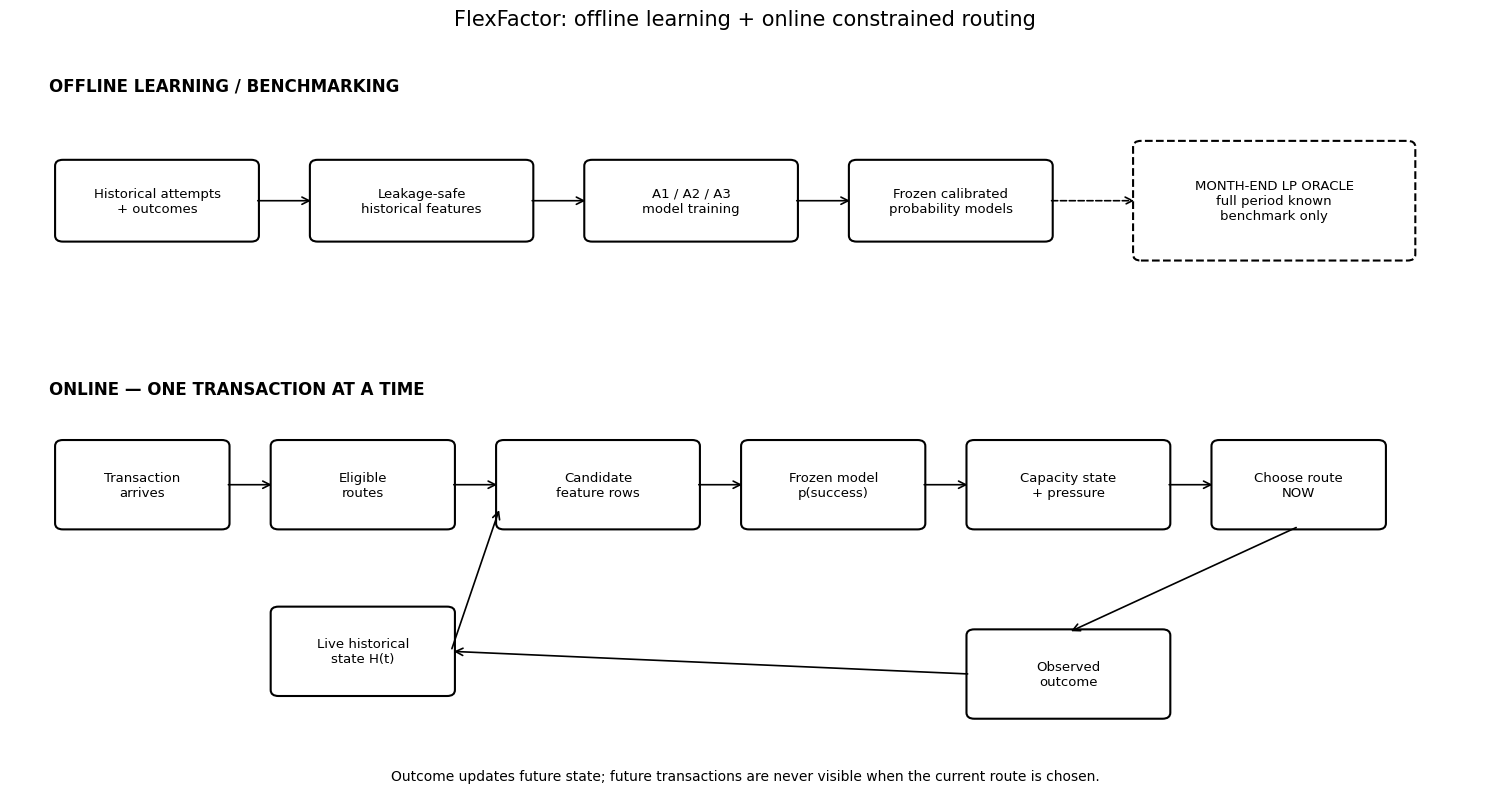

In [16]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(15, 8.2))
ax.set_xlim(0, 15)
ax.set_ylim(0, 10)
ax.axis("off")

def box(x, y, w, h, text, linewidth=1.5, linestyle="-"):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        fill=False,
        linewidth=linewidth,
        linestyle=linestyle,
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=9.5,
    )
    return (x, y, w, h)

def arrow_xy(x1, y1, x2, y2, linestyle="-"):
    ax.add_patch(FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=13,
        linewidth=1.2,
        linestyle=linestyle,
    ))

# ------------------------------------------------------------
# Offline layer
# ------------------------------------------------------------
ax.text(
    0.4, 9.35,
    "OFFLINE LEARNING / BENCHMARKING",
    fontsize=12,
    weight="bold",
)

hist_data = box(
    0.5, 7.4, 2.0, 1.0,
    "Historical attempts\n+ outcomes",
)
features = box(
    3.1, 7.4, 2.2, 1.0,
    "Leakage-safe\nhistorical features",
)
training = box(
    5.9, 7.4, 2.1, 1.0,
    "A1 / A2 / A3\nmodel training",
)
frozen = box(
    8.6, 7.4, 2.0, 1.0,
    "Frozen calibrated\nprobability models",
)

arrow_xy(2.5, 7.9, 3.1, 7.9)
arrow_xy(5.3, 7.9, 5.9, 7.9)
arrow_xy(8.0, 7.9, 8.6, 7.9)

lp = box(
    11.5, 7.15, 2.8, 1.5,
    "MONTH-END LP ORACLE\nfull period known\nbenchmark only",
    linestyle="--",
)

arrow_xy(10.6, 7.9, 11.5, 7.9, linestyle="--")

# ------------------------------------------------------------
# Online layer
# ------------------------------------------------------------
ax.text(
    0.4, 5.35,
    "ONLINE — ONE TRANSACTION AT A TIME",
    fontsize=12,
    weight="bold",
)

tx = box(
    0.5, 3.6, 1.7, 1.1,
    "Transaction\narrives",
)
eligible = box(
    2.7, 3.6, 1.8, 1.1,
    "Eligible\nroutes",
)
state = box(
    2.7, 1.4, 1.8, 1.1,
    "Live historical\nstate H(t)",
)
candidate = box(
    5.0, 3.6, 2.0, 1.1,
    "Candidate\nfeature rows",
)
score = box(
    7.5, 3.6, 1.8, 1.1,
    "Frozen model\np(success)",
)
capacity = box(
    9.8, 3.6, 2.0, 1.1,
    "Capacity state\n+ pressure",
)
decision = box(
    12.3, 3.6, 1.7, 1.1,
    "Choose route\nNOW",
)
outcome = box(
    9.8, 1.1, 2.0, 1.1,
    "Observed\noutcome",
)

for a, b in [
    (tx, eligible),
    (eligible, candidate),
    (candidate, score),
    (score, capacity),
    (capacity, decision),
]:
    arrow_xy(
        a[0] + a[2],
        a[1] + a[3] / 2,
        b[0],
        b[1] + b[3] / 2,
    )

arrow_xy(
    state[0] + state[2],
    state[1] + state[3] / 2,
    candidate[0],
    candidate[1] + 0.25,
)

arrow_xy(
    decision[0] + decision[2] / 2,
    decision[1],
    outcome[0] + outcome[2] / 2,
    outcome[1] + outcome[3],
)

arrow_xy(
    outcome[0],
    outcome[1] + outcome[3] / 2,
    state[0] + state[2],
    state[1] + state[3] / 2,
)

ax.text(
    7.5,
    0.25,
    "Outcome updates future state; future transactions are never visible when the current route is chosen.",
    ha="center",
    fontsize=10,
)

ax.set_title(
    "FlexFactor: offline learning + online constrained routing",
    fontsize=15,
    pad=12,
)
plt.tight_layout()
plt.show()

# Part IX — The offline LP oracle

## 10. Month-end hindsight benchmark — not a deployable routing policy

The LP answers an **offline benchmark question**:

> If the entire month's candidate transactions and model scores were already known at the end of the month, what is the best assignment that could have been made under the route-volume constraints?

Only after the period has been aggregated can the LP jointly coordinate all assignments:

$$
\max_x \sum_{i,r}x_{ir}\hat p_{ir}
$$

or, for expected approved transaction value,

$$
\max_x \sum_{i,r}x_{ir}Amount_i\hat p_{ir}
$$

subject to:

$$
\sum_r x_{ir}=1
$$

and route-volume bounds.

The LP is useful because it establishes a **full-hindsight model-implied oracle**. It tells us how much opportunity exists under the frozen model and constraints. It cannot be used as the live routing algorithm because it sees transactions that had not yet arrived.

In [17]:
policy_path = PROJECT_ROOT / "artifacts" / "reference_policy_results.csv"

if policy_path.exists():
    policy = pd.read_csv(policy_path)
else:
    # Frozen headline policy results fallback.
    policy = pd.DataFrame([
        ["greedy", 0.00, 87.3506, 0.462719, 599132, 0.420790],
        ["success_pressure", 0.10, 162.606, 0.861364, 1067185, 0.749519],
        ["balanced_success_pressure", 0.15, 161.694, 0.856533, 1084469, 0.761658],
        ["value_pressure", 0.20, 140.055, 0.741909, 1212111, 0.851305],
        ["LP_success", None, 188.777, 1.0, 1299129, None],
        ["LP_value", None, 173.116, None, 1423827, 1.0],
    ], columns=[
        "policy","lambda","expected_added_approvals",
        "success_opportunity_capture","expected_added_approved_value",
        "value_opportunity_capture"
    ])

display(policy)
print('100% LP success opportunity = +188.777 model-implied approvals relative to historical routing.')
print('Success-optimal LP also adds ≈1.299M expected approved transaction value.')
print('Value-optimal LP adds ≈1.424M expected approved transaction value.')

,policy,lambda,expected_added_approvals,success_capture,expected_added_approved_value,value_capture
0,greedy,0.00,87.351,0.462719,599132,0.420790
1,success_pressure,0.10,162.606,0.861364,1067185,0.749519
2,balanced_pressure,0.15,161.694,0.856533,1084469,0.761658
3,value_pressure,0.20,140.055,0.741909,1212111,0.851305
4,LP_success,NaN,188.777,1.000000,1299129,NaN
5,LP_value,NaN,173.116,NaN,1423827,1.000000


100% LP success opportunity = +188.777 model-implied approvals relative to historical routing.
Success-optimal LP also adds ≈1.299M expected approved transaction value.
Value-optimal LP adds ≈1.424M expected approved transaction value.


### Meaning of the “100% LP opportunity”

“100%” means **100% of the incremental objective found by the full-hindsight LP**, relative to the model-scored historical routing baseline and under the same capacity constraints.

It does **not** mean:

- 100% transaction approval;
- 100% real-world uplift;
- causal proof.

For the June reference period, the success-optimal LP found approximately **+188.8 model-implied approvals** and **+1.299M expected approved transaction value**. The value-optimal LP found approximately **+1.424M expected approved transaction value**.

The online policy is judged partly by how much of this hindsight opportunity it can recover **without knowing the future**.

# Part X — The online decision problem

The real business decision is fundamentally different from the LP.

When transaction $i$ arrives at time $t$, the router knows:

- the current transaction;
- the routes currently eligible;
- the historical state $H_t$;
- the route capacity already consumed.

It does **not** know which transactions will arrive later in the day or month.

The route choice must therefore be made immediately and is effectively irreversible.

A naive greedy rule,

$$
r_i^{greedy}=\arg\max_r\hat p_{ir},
$$

can repeatedly consume the route that looks best **right now**, leaving too little capacity for later transactions that may benefit from it even more.

The online objective is therefore:

> **Capture as much of the LP's model-implied opportunity as possible while making decisions chronologically and preserving scarce route capacity.**

## Pressure as an online shadow price

Let:

- $B_{r,t}$ = cumulative reference/baseline usage of route $r$ by time $t$;
- $A_{r,t}$ = cumulative usage produced by the online policy.

Define:

$$
Pressure_{r,t}
=
\frac{A_{r,t}-B_{r,t}}
{\max(0.3B_{r,t},1)}
$$

A positive pressure means the policy is using the route **more heavily** than the reference pace. A negative pressure means it is using the route **less heavily**.

The success-policy score is:

$$
Score_{ir,t}
=
\hat p_{ir,t}
-
\lambda Pressure_{r,t}
$$

The model probability remains the estimate of approval probability. Pressure is a **decision-layer scarcity adjustment**.

### What does $\lambda$ mean?

$\lambda$ controls the trade-off between **local predicted success** and **preserving route capacity**.

- $\lambda=0$: no scarcity penalty — the policy collapses to greedy probability maximization.
- small $\lambda$: route pressure matters only when candidate probabilities are close.
- larger $\lambda$: the policy is increasingly willing to choose a slightly lower-probability route in order to avoid over-consuming a scarce route.

So $\lambda$ is not another model parameter inside XGBoost. It belongs to the online optimization policy.

The main success-policy reference uses $\lambda=0.10$; nearby values are examined later to verify that the result is not dependent on one magic setting.

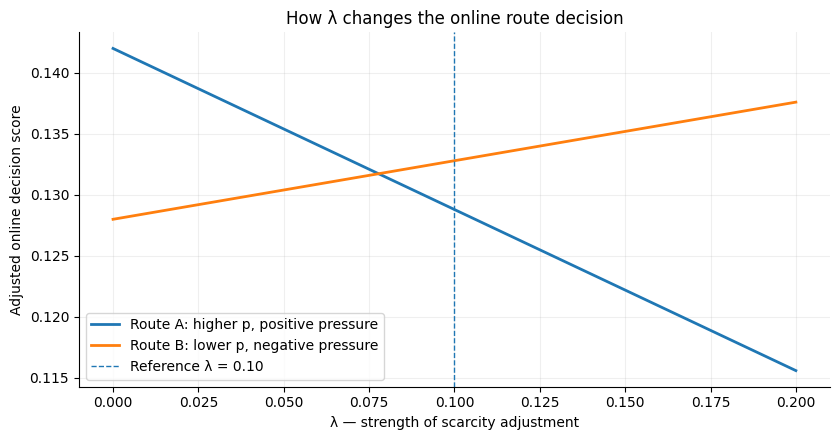

In this illustration, the preferred route switches at approximately λ=0.078.


In [18]:
# Conceptual illustration of lambda.
# Two routes for the same transaction:
# Route A has the higher raw model probability but is slightly over-used.
# Route B has a slightly lower probability but is slightly under-used.

lambdas = np.linspace(0, 0.20, 101)

p_a = 0.142
p_b = 0.128

pressure_a = 0.132
pressure_b = -0.048

score_a = p_a - lambdas * pressure_a
score_b = p_b - lambdas * pressure_b

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(
    lambdas,
    score_a,
    linewidth=2,
    label="Route A: higher p, positive pressure",
)
ax.plot(
    lambdas,
    score_b,
    linewidth=2,
    label="Route B: lower p, negative pressure",
)
ax.axvline(
    0.10,
    linestyle="--",
    linewidth=1,
    label="Reference λ = 0.10",
)

ax.set_title("How λ changes the online route decision")
ax.set_xlabel("λ — strength of scarcity adjustment")
ax.set_ylabel("Adjusted online decision score")
ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

switch_lambda = (p_a - p_b) / (pressure_a - pressure_b)

print(
    f"In this illustration, the preferred route switches at "
    f"approximately λ={switch_lambda:.3f}."
)

The crossing point illustrates the business logic: when $\lambda$ is small, the probability advantage of Route A dominates. Once scarcity is priced strongly enough, Route B becomes the better **system-level** decision even though its raw predicted approval probability is lower.

## 11. Opportunity capture and route-capacity behavior

The route constraint is approximately a ±30% band around the reference route volume.

For route $r$, define its **absolute route deviation** as:

$$
d_r
=
\left|
\frac{V_r^{policy}}
{V_r^{baseline}}
-
1
\right|
$$

For example, $d_r=0.10$ means the policy finished 10% away from the baseline route volume.

The table also reports how many routes are **near the 30% boundary**. Here “near” means:

$$
d_r \geq 0.27
$$

so the route is within three percentage points of the hard ±30% limit.

A good online policy should recover model-implied benefit without repeatedly driving many routes directly against their constraint.

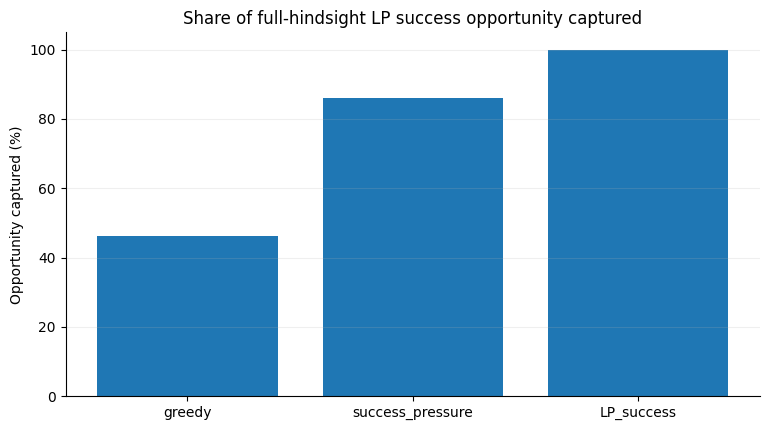

,policy,routes_with_abs_deviation_ge_27pct,routes_total,mean_abs_route_deviation
0,Greedy,9,12,26.36%
1,Success pressure λ=0.10,1,12,10.26%
2,Balanced pressure λ=0.15,1,12,7.60%
3,Value pressure λ=0.20,1,12,7.53%


In [19]:
show = policy[
    policy["policy"].isin(
        ["greedy", "success_pressure", "LP_success"]
    )
].copy()

fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(
    show["policy"],
    100 * show["success_capture"],
)
ax.set_title(
    "Share of full-hindsight LP success opportunity captured"
)
ax.set_ylabel("Opportunity captured (%)")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

capacity = pd.DataFrame({
    "policy": [
        "Greedy",
        "Success pressure λ=0.10",
        "Balanced pressure λ=0.15",
        "Value pressure λ=0.20",
    ],
    "routes_with_abs_deviation_ge_27pct": [9, 1, 1, 1],
    "routes_total": [12, 12, 12, 12],
    "mean_abs_route_deviation": [
        0.2636,
        0.1026,
        0.0760,
        0.0753,
    ],
})

display(
    capacity.style.format({
        "mean_abs_route_deviation": "{:.2%}",
    })
)

Greedy captures only about **46%** of the model-implied LP success opportunity and pushes **9 of 12 routes** close to the ±30% boundary.

The $\lambda=0.10$ pressure policy captures about **86%** of the LP success opportunity while reducing the mean absolute route-volume deviation from roughly **26% to 10%** and leaving only **1 of 12 routes** near the boundary.

This is the central optimization result: pricing scarcity recovers much more of the global hindsight opportunity than greedy while producing a healthier route allocation.

# Part XI — Worked online routing example

The real backtest contains thousands of candidate rows and cumulative state variables, which is useful for evaluation but not ideal for explaining the mechanism.

The following **small synthetic example** is deliberately pedagogical. The transaction contexts and probabilities are illustrative; they are **not additional empirical results**.

The purpose is to show exactly how the production-style system would process transactions one by one.

Assume we are already part-way through a month. The frozen model has produced a probability for each candidate route, and the policy currently has the route-usage state shown below.

In [20]:
synthetic_transactions = pd.DataFrame([
    {
        "transaction": "T1",
        "amount": 120,
        "merchant": "M1",
        "issuer": "Issuer-X",
        "card_type": "credit",
        "reference_route": "A",
        "p_A": 0.142,
        "p_B": 0.128,
        "p_C": 0.105,
    },
    {
        "transaction": "T2",
        "amount": 480,
        "merchant": "M2",
        "issuer": "Issuer-Y",
        "card_type": "debit",
        "reference_route": "A",
        "p_A": 0.135,
        "p_B": 0.132,
        "p_C": 0.118,
    },
    {
        "transaction": "T3",
        "amount": 75,
        "merchant": "M1",
        "issuer": "Issuer-Z",
        "card_type": "credit",
        "reference_route": "B",
        "p_A": 0.102,
        "p_B": 0.126,
        "p_C": 0.120,
    },
    {
        "transaction": "T4",
        "amount": 900,
        "merchant": "M3",
        "issuer": "Issuer-X",
        "card_type": "credit",
        "reference_route": "C",
        "p_A": 0.150,
        "p_B": 0.131,
        "p_C": 0.108,
    },
])

initial_route_state = pd.DataFrame([
    {
        "route": "A",
        "baseline_cumulative": 100,
        "policy_cumulative": 105,
    },
    {
        "route": "B",
        "baseline_cumulative": 70,
        "policy_cumulative": 69,
    },
    {
        "route": "C",
        "baseline_cumulative": 50,
        "policy_cumulative": 47,
    },
])

print("Synthetic incoming transactions")
display(synthetic_transactions)

print("Route state immediately before T1")
display(initial_route_state)

Synthetic incoming transactions


,transaction,amount,merchant,issuer,card_type,reference_route,p_A,p_B,p_C
0,T1,120,M1,Issuer-X,credit,A,0.142,0.128,0.105
1,T2,480,M2,Issuer-Y,debit,A,0.135,0.132,0.118
2,T3,75,M1,Issuer-Z,credit,B,0.102,0.126,0.120
3,T4,900,M3,Issuer-X,credit,C,0.150,0.131,0.108


Route state immediately before T1


,route,baseline_cumulative,policy_cumulative
0,A,100,105
1,B,70,69
2,C,50,47


### Step-by-step replay

For each transaction:

$$
\text{context}
\rightarrow
\text{candidate routes}
\rightarrow
\hat p_{ir}
\rightarrow
Pressure_{r,t}
\rightarrow
Score_{ir,t}
\rightarrow
\text{route choice}
\rightarrow
\text{update route state}
$$

The reference route is used only to advance the baseline comparison in this offline demonstration. In a live deployment, the reference pace/capacity target would come from the business routing constraints rather than from knowing a future historical assignment.

In [21]:
from collections import defaultdict

lambda_demo = 0.10
capacity_shift = 0.30
routes = ["A", "B", "C"]

baseline_count = {
    row["route"]: int(row["baseline_cumulative"])
    for _, row in initial_route_state.iterrows()
}

policy_count = {
    row["route"]: int(row["policy_cumulative"])
    for _, row in initial_route_state.iterrows()
}

decision_log = []

for _, tx in synthetic_transactions.iterrows():

    # In the historical replay, the baseline counter advances using the
    # reference/logged route for the same event.
    baseline_count[tx["reference_route"]] += 1

    candidate_rows = []

    for route in routes:
        p = float(tx[f"p_{route}"])

        pressure = (
            policy_count[route] - baseline_count[route]
        ) / max(
            capacity_shift * baseline_count[route],
            1.0,
        )

        adjusted = p - lambda_demo * pressure

        candidate_rows.append({
            "route": route,
            "raw_p_success": p,
            "baseline_cumulative": baseline_count[route],
            "policy_cumulative_before": policy_count[route],
            "pressure": pressure,
            "adjusted_score": adjusted,
        })

    candidates_demo = pd.DataFrame(candidate_rows)

    greedy_route = (
        candidates_demo
        .sort_values("raw_p_success", ascending=False)
        .iloc[0]["route"]
    )

    selected_route = (
        candidates_demo
        .sort_values("adjusted_score", ascending=False)
        .iloc[0]["route"]
    )

    candidates_demo["greedy_choice"] = (
        candidates_demo["route"].eq(greedy_route)
    )
    candidates_demo["policy_choice"] = (
        candidates_demo["route"].eq(selected_route)
    )

    print(
        f"\n{tx['transaction']} | amount={tx['amount']} "
        f"| merchant={tx['merchant']} | issuer={tx['issuer']}"
    )

    display(
        candidates_demo.style.format({
            "raw_p_success": "{:.3f}",
            "pressure": "{:+.3f}",
            "adjusted_score": "{:.3f}",
        })
    )

    decision_log.append({
        "transaction": tx["transaction"],
        "reference_route": tx["reference_route"],
        "greedy_route": greedy_route,
        "pressure_policy_route": selected_route,
        "greedy_p": float(
            candidates_demo.loc[
                candidates_demo["route"].eq(greedy_route),
                "raw_p_success",
            ].iloc[0]
        ),
        "selected_p": float(
            candidates_demo.loc[
                candidates_demo["route"].eq(selected_route),
                "raw_p_success",
            ].iloc[0]
        ),
        "moved_vs_reference": (
            selected_route != tx["reference_route"]
        ),
        "different_from_greedy": (
            selected_route != greedy_route
        ),
    })

    # The chosen route consumes capacity for the next decision.
    policy_count[selected_route] += 1


decision_summary = pd.DataFrame(decision_log)

print("\nDecision summary")
display(
    decision_summary.style.format({
        "greedy_p": "{:.3f}",
        "selected_p": "{:.3f}",
    })
)

final_state = pd.DataFrame([
    {
        "route": route,
        "baseline_cumulative": baseline_count[route],
        "policy_cumulative": policy_count[route],
        "signed_deviation": (
            policy_count[route] / baseline_count[route] - 1
        ),
    }
    for route in routes
])

print("\nRoute state after the four decisions")
display(
    final_state.style.format({
        "signed_deviation": "{:+.2%}",
    })
)


T1 | amount=120 | merchant=M1 | issuer=Issuer-X


,route,raw_p_success,baseline_cumulative,policy_cumulative_before,pressure,adjusted_score,greedy_choice,policy_choice
0,A,0.142,101,105,+0.132,0.129,True,False
1,B,0.128,70,69,-0.048,0.133,False,True
2,C,0.105,50,47,-0.200,0.125,False,False



T2 | amount=480 | merchant=M2 | issuer=Issuer-Y


,route,raw_p_success,baseline_cumulative,policy_cumulative_before,pressure,adjusted_score,greedy_choice,policy_choice
0,A,0.135,102,105,+0.098,0.125,True,False
1,B,0.132,70,70,+0.000,0.132,False,False
2,C,0.118,50,47,-0.200,0.138,False,True



T3 | amount=75 | merchant=M1 | issuer=Issuer-Z


...

,route,raw_p_success,baseline_cumulative,policy_cumulative_before,pressure,adjusted_score,greedy_choice,policy_choice
0,A,0.150,102,105,+0.098,0.140,True,True
1,B,0.131,71,70,-0.047,0.136,False,False
2,C,0.108,51,49,-0.131,0.121,False,False



Decision summary


,transaction,reference_route,greedy_route,pressure_policy_route,greedy_p,selected_p,moved_vs_reference,different_from_greedy
0,T1,A,A,B,0.142,0.128,True,True
1,T2,A,A,C,0.135,0.118,True,True
2,T3,B,B,C,0.126,0.120,True,True
3,T4,C,A,A,0.150,0.150,True,False



Route state after the four decisions


,route,baseline_cumulative,policy_cumulative,signed_deviation
0,A,102,106,+3.92%
1,B,71,70,-1.41%
2,C,51,49,-3.92%


### What happens in the worked example?

For **T1**, Route A has the highest raw approval probability, so greedy would use A. But A is already somewhat over-used while B is slightly under-used. At $\lambda=0.10$, that small scarcity difference is enough for the policy to choose B.

For later transactions, the state has changed because earlier choices consumed capacity. Therefore the same probability table would not necessarily lead to the same route decision at a different point in the month.

This is the essence of the online system:

> **The prediction is transaction-specific; the final decision is transaction-specific *and state-dependent*.**

The example also clarifies why the LP and online policy are different. The LP coordinates all transactions simultaneously after seeing the whole period. The online router sees one transaction, commits a route, updates state, and only then receives the next transaction.

# Part XII — Robustness: not one magic $\lambda$

## 13. Later-period policy robustness

A useful online policy should not work only at one finely tuned value of $\lambda$.

The policy layer was developed on the earlier portion of June and then examined on the later June period. This is **robustness evidence**, not a pristine production holdout, because the broader June policy analysis had already been inspected during development.

Two operational quantities are useful when reading these results:

$$
Movement
=
\frac{1}{N}
\sum_i
\mathbf{1}
\left(
R_i^{policy}
\neq
R_i^{logged}
\right)
$$

**Movement** is the fraction of replayed events whose suggested route differs from the historical/logged route. It measures how much operational routing behavior changes; it is not itself a measure of benefit.

**Route deviation**, defined earlier, measures how far the final aggregate route volume moves from its reference volume.

The goal is not to minimize movement at all costs. The goal is to obtain a strong modeled objective while keeping the route allocation feasible and operationally interpretable.

In [22]:
rob = ART["robustness"]

val_path = (
    rob / "summary/validation_overall.csv"
    if rob
    else None
)

if val_path and val_path.exists():
    validation = pd.read_csv(val_path)

    preferred_cols = [
        c for c in [
            "policy",
            "lambda",
            "expected_added_approvals",
            "expected_added_approved_value",
            "movement",
            "movement_rate",
            "success_capture",
            "value_capture",
        ]
        if c in validation.columns
    ]

    if preferred_cols:
        display(validation[preferred_cols])
    else:
        display(validation)

    daily_path = (
        rob / "summary/validation_daily_rollup.csv"
    )

    if daily_path.exists():
        daily = pd.read_csv(daily_path)

        print("\nDaily later-period robustness")
        display(daily)

else:
    validation = pd.DataFrame([
        ["greedy", 0.00, 39.75, 289380],
        ["success λ=.03", 0.03, 73.54, 503230],
        ["success λ=.10", 0.10, 76.77, 536520],
        ["success λ=.15", 0.15, 77.16, 553990],
        ["value λ=.20", 0.20, 66.25, 609360],
    ], columns=[
        "policy",
        "lambda",
        "expected_added_approvals",
        "expected_added_approved_value",
    ])

    display(validation)

,policy,expected_added_approvals,expected_added_approved_value,movement_rate
0,greedy,39.750067,289379.767354,0.553722
1,success_pressure_0.0300,73.539092,503226.216067,0.751710
2,value_pressure_0.2000,66.249381,609359.686285,0.725956
3,success_pressure_0.1000,76.765661,536515.144271,0.758149
4,success_pressure_0.1500,77.161091,553985.596234,0.752515



Daily later-period robustness


,policy,validation_days,days_beating_greedy_success,days_beating_greedy_value,min_daily_added_approvals,mean_daily_added_approvals,min_daily_added_value,mean_daily_added_value
0,greedy,7,0,0,1.341158,5.678581,9952.095337,41339.966765
1,success_pressure_0.0300,7,7,7,2.577915,10.505585,16146.659206,71889.459438
2,success_pressure_0.1000,7,7,7,2.890710,10.966523,20999.822814,76645.020610
3,success_pressure_0.1500,7,7,7,3.214819,11.023013,30341.950383,79140.799462
4,value_pressure_0.2000,7,7,7,3.128220,9.464197,30739.997199,87051.383755


### Robustness interpretation

The important result is the **region**, not a single point estimate.

On the later June period:

- the moderate success-pressure policies remained substantially stronger than greedy on modeled approvals;
- the value-oriented $\lambda=0.20$ policy traded some modeled approvals for more expected approved transaction value;
- the main pressure policies beat greedy on both modeled approvals and modeled approved value across all 7 later-period days in the saved robustness analysis.

That makes the policy story more credible than selecting one $\lambda$ from one aggregate table. The system exhibits a stable trade-off surface between probability maximization and scarcity preservation.

# Part XIII — Scientific interpretation

Offline routing evaluation has an unavoidable counterfactual limitation.

For a historical transaction, only the outcome of the route that was actually used is observed:

$$
Y_i(R_{logged})
$$

The outcome under an alternative route is not observed:

$$
Y_i(R_{alternative})
$$

Therefore the project intentionally separates **predictive evidence** from **policy opportunity estimates**.

The probability models can be evaluated factually on the historical route. The alternative-route optimizer can then be evaluated coherently under those frozen calibrated probabilities, but that remains a model-dependent counterfactual estimate rather than causal proof.

## Claim taxonomy — what each result actually means

In [23]:
display(pd.DataFrame([
    ["AUC / AP / log-loss / Brier / ECE", "FACTUAL", "Observed-route predictive quality"],
    ["Capacity compliance / route shares / movement", "OPERATIONAL", "Direct property of replayed assignments"],
    ["Expected approvals / approved amount on alternative routes", "MODEL-DEPENDENT", "Counterfactual estimate under frozen calibrated probabilities"],
    ["Observed success when suggestion matches logged route", "DESCRIPTIVE ONLY", "Overlap subset; not an unbiased policy-value estimate"],
], columns=["metric", "claim type", "interpretation"]))

,metric,claim type,interpretation
0,AUC / AP / log-loss / Brier / ECE,FACTUAL,Observed-route predictive quality
1,Capacity compliance / route shares / movement,OPERATIONAL,Direct property of replayed assignments
2,Expected approvals / approved amount on altern...,MODEL-DEPENDENT,Counterfactual estimate under frozen calibrate...
3,Observed success when suggestion matches logge...,DESCRIPTIVE ONLY,Overlap subset; not an unbiased policy-value e...


## 14. Final validation status

In [24]:
display(pd.DataFrame([
['Predictive quality','Chronologically validated on observed routes'],
['Calibration','Measured on factual route outcomes'],
['Capacity behavior','Validated in chronological replay'],
['LP / pressure gains','Counterfactual, calibrated-model-implied'],
['True production uplift','Requires controlled online/A-B test'],
],columns=['layer','status']))

,layer,status
0,Predictive quality,Chronologically validated on observed routes
1,Calibration,Measured on factual route outcomes
2,Capacity behavior,Validated in chronological replay
3,LP / pressure gains,"Counterfactual, calibrated-model-implied"
4,True production uplift,Requires controlled online/A-B test


# Conclusion

The project started from a simple financial decision:

> **When a payment attempt can be sent through several eligible routes, which route should be used now?**

A static “best route” rule is not enough. Route performance depends on transaction context, approval behavior changes through time, retry attempts expose additional information, and route capacity means the route with the highest predicted probability cannot be consumed without limit.

The final architecture therefore separates the problem into two layers.

### Predictive layer

Three stage-specific XGBoost models estimate the probability of success for A1, A2 and A3 using transaction context, candidate-route information, prior-attempt information where legally available, and leakage-safe historical state.

The historical state gives a tabular model memory through contextual exponentially decayed features at multiple half-lives:

$$
3,\ 14,\ 60,\ 180 \text{ days}
$$

This allows the model to represent both rapid deterioration/improvement and slower structural behavior without imposing one arbitrary rolling-window cutoff.

On the untouched June evaluation, the final models achieved approximately:

- **A1:** ROC-AUC 0.797, AP 0.324;
- **A2:** ROC-AUC 0.794, AP 0.212;
- **A3:** ROC-AUC 0.871, AP 0.137;

with low Brier error and ECE. The calibration analysis additionally shows that mean predicted success is close to the success actually observed on the logged routes, while sparse extreme A2/A3 predictions are treated explicitly rather than visually over-weighted.

### Decision layer

Prediction alone does not solve the routing problem because route capacity couples decisions across transactions.

A full-hindsight LP is used **after the period** as an offline oracle: given the whole candidate set, frozen model scores and route constraints, it finds the globally optimal model-implied assignment. This provides a benchmark, not a deployable policy.

The live-style router instead operates chronologically. Each transaction arrives, candidate routes are scored, current route usage is compared with the reference pace, and a pressure/shadow-price term adjusts the local probability score:

$$
Score_{ir,t}
=
\hat p_{ir,t}
-
\lambda Pressure_{r,t}
$$

This lets the system preserve capacity for future transactions it has not yet seen.

### Model-implied opportunity

For the June reference period, the full-hindsight success LP identified approximately **+188.8 expected approvals** relative to the model-scored historical routing baseline, together with about **+1.299M expected approved transaction value**. The value-optimal LP identified roughly **+1.424M expected approved transaction value**.

Naive greedy routing recovered only about **46%** of the LP success opportunity and pushed most routes close to their capacity boundary.

The $\lambda=0.10$ success-pressure policy recovered about **86%** of the model-implied LP success opportunity while producing substantially healthier route-volume behavior: mean absolute route deviation fell from roughly **26% under greedy to 10%**, and only **1 of 12 routes** remained near the ±30% capacity boundary.

Nearby pressure values also performed strongly in the later-period robustness analysis, suggesting that the result is not dependent on one fragile hyperparameter setting.

### What has and has not been proven

The predictive results are factual historical evidence because the logged-route outcomes were observed.

The alternative-route gains are **model-implied counterfactual opportunity**, not causal production lift. A historical dataset cannot reveal what would actually have happened had every transaction been routed differently.

The production path is therefore:

$$
\text{offline validation}
\rightarrow
\text{shadow deployment}
\rightarrow
\text{controlled A/B test}
\rightarrow
\text{gradual live rollout}
$$

The final contribution is thus not simply a classifier. It is an end-to-end framework for **dynamic, capacity-constrained payment routing**:

$$
\boxed{
\text{temporal state estimation}
+
\text{stage-specific probability models}
+
\text{offline optimization benchmark}
+
\text{online scarcity-aware decisioning}
}
$$

The core design principle is simple:

> **The model needs memory because the environment changes. The optimizer needs scarcity awareness because the best-looking route cannot be used infinitely.**